## Fetch and Display NYSE Stock Data

### yfinance module 추가
nyse 종목

In [1]:
# _tsa_00.py
# time series stuff, basic
# 그리기
# 시계열, 추세, 계절성 조정, 이동평균, 이런 것들.
# 자기공분산, 자기상관, 단위근
# ARIMA 중 AR(p)
# 기타... 단순한 내용만 간략하게.

# 코랩 추가.
!pip install yfinance

import os
import numpy as np                          # numpy 라이브러리 전체.
import pandas as pd                         # pandas 라이브러리 전체, 시계열(기본) 여기 있네.
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf                       ## NYSE 데이터 모듈
from scipy import stats, optimize, linalg   # scipy 라이브러리 하부 모듈.
from statsmodels.tsa import stattools       # time series analysis
from statsmodels.tsa.arima.model import ARIMA # 이거 가능하다 이거지. 이거 대문자네. 꼭.
from statsmodels.tsa.ar_model import AutoReg


### Tickers and close prices

In [5]:
import pandas as pd
import yfinance as yf

# 1. 나스닥 주요 상위 종목 티커 리스트 정의
tickers = ["AAPL", "MSFT", "NVDA", "AMZN", "META", "GOOGL", "TSLA", "AVGO", "COST", "NFLX", "SKHY", "MU"]
stock_data = []

# 2. 각 종목의 세부 정보 가져오기
for ticker in tickers:
    stock = yf.Ticker(ticker)
    info = stock.info

    stock_data.append({
        "티커": ticker,
        "기업명": info.get("longName", "N/A"),
        "섹터": info.get("sector", "N/A"),
        "현재가($)": info.get("currentPrice", "N/A"),
        "시가총액($)": f"{info.get('marketCap', 0):,}"
    })

# 3. 데이터프레임 변환 및 출력
df_tckr = pd.DataFrame(stock_data)
print(df_tckr)

df_dat = yf.download(tickers, period='1y') #, multi_level_index=False)
df_dat.info()   # ticker마다 close, open, volume 등

df_dat_cls = df_dat['Close'].copy()
df_dat_cls

/tmp/ipykernel_1380/461224751.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_dat = yf.download(tickers, period='1y') #, multi_level_index=False)
[                       0%                       ]

       티커                           기업명                      섹터   현재가($)  \
0    AAPL                    Apple Inc.              Technology   316.22   
1    MSFT         Microsoft Corporation              Technology   493.95   
2    NVDA            NVIDIA Corporation              Technology   225.73   
3    AMZN              Amazon.com, Inc.       Consumer Cyclical   256.97   
4    META          Meta Platforms, Inc.  Communication Services   613.48   
5   GOOGL                 Alphabet Inc.  Communication Services   338.36   
6    TSLA                   Tesla, Inc.       Consumer Cyclical   368.16   
7    AVGO                 Broadcom Inc.              Technology   368.56   
8    COST  Costco Wholesale Corporation      Consumer Defensive   910.18   
9    NFLX                 Netflix, Inc.  Communication Services    76.77   
10   SKHY                 SK hynix Inc.              Technology   185.55   
11     MU       Micron Technology, Inc.              Technology  1000.26   

           

[*********************100%***********************]  12 of 12 completed


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-09-09 to 2026-09-08
Data columns (total 60 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, AAPL)    251 non-null    float64
 1   (Close, AMZN)    251 non-null    float64
 2   (Close, AVGO)    251 non-null    float64
 3   (Close, COST)    251 non-null    float64
 4   (Close, GOOGL)   251 non-null    float64
 5   (Close, META)    251 non-null    float64
 6   (Close, MSFT)    251 non-null    float64
 7   (Close, MU)      251 non-null    float64
 8   (Close, NFLX)    251 non-null    float64
 9   (Close, NVDA)    251 non-null    float64
 10  (Close, SKHY)    42 non-null     float64
 11  (Close, TSLA)    251 non-null    float64
 12  (High, AAPL)     251 non-null    float64
 13  (High, AMZN)     251 non-null    float64
 14  (High, AVGO)     251 non-null    float64
 15  (High, COST)     251 non-null    float64
 16  (High, GOOGL)    251 non-null    float64
 1

Ticker,AAPL,AMZN,AVGO,COST,GOOGL,META,MSFT,MU,NFLX,NVDA,SKHY,TSLA
Date,,,,,,,,,,,,
2025-09-09,233.487518,238.240005,334.221161,973.569641,239.008423,763.198608,494.342682,135.023270,126.324997,170.532852,NaN,346.970001
2025-09-10,225.955322,230.330002,366.881836,950.742737,238.549622,749.523438,496.286743,139.775635,124.771004,177.094131,NaN,347.790009
2025-09-11,229.183411,229.949997,357.014160,958.726257,239.746506,748.447021,496.921478,150.328735,120.349998,176.944336,NaN,368.809998
2025-09-12,233.208542,228.149994,357.252380,962.285461,240.175385,753.121643,505.738922,156.978043,118.844002,177.593491,NaN,395.940002
2025-09-15,235.828857,231.429993,361.441711,954.530701,250.957336,762.201843,511.154388,157.517181,120.225998,177.523575,NaN,410.040009
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-01,325.130005,254.919998,369.679993,939.960022,334.804779,578.539978,501.019989,933.440002,80.809998,217.440002,160.779999,356.089996
2026-09-02,324.959991,254.979996,367.239990,928.479980,336.903442,592.849976,496.820007,956.080017,82.730003,224.410004,164.979996,357.010010
2026-09-03,328.209991,258.899994,357.160004,925.409973,342.260010,610.679993,510.119995,958.159973,82.669998,228.449997,163.679993,376.369995


### subplots?

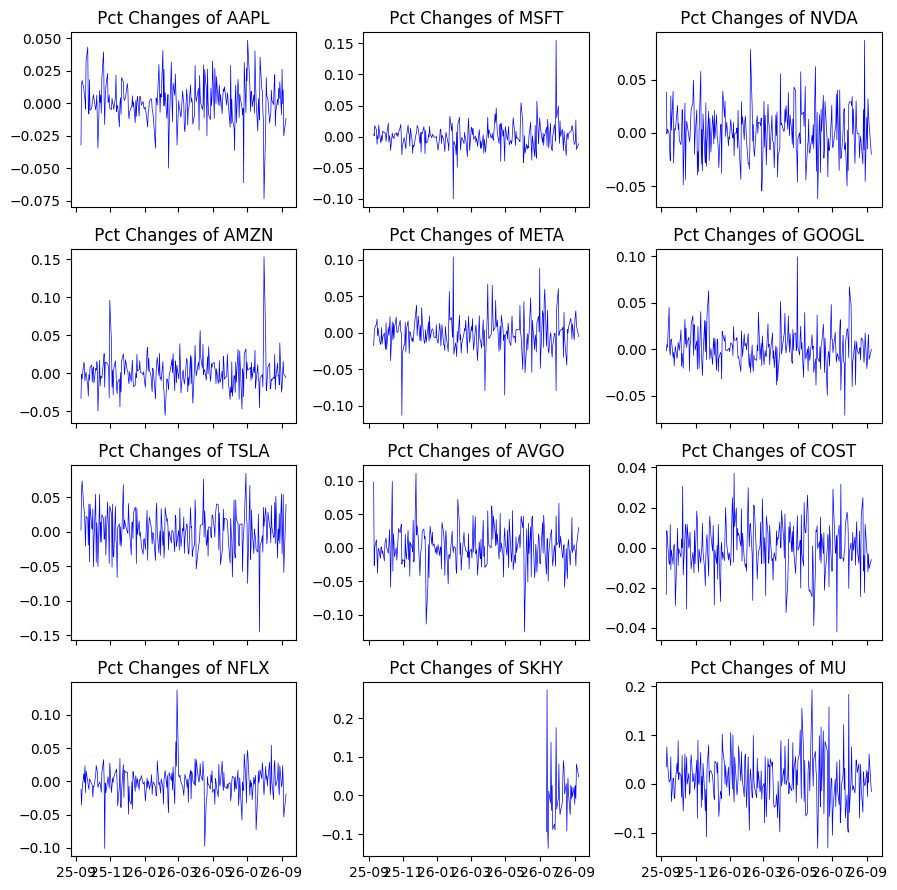

In [7]:
# NYSE daily stock prices and trading volumes
# 변수로 받는 방법.
yymmdd = df_dat.index   # 자료를 불러올 때, 자동으로 기준 인덱스로 설정된다고 함.
yymmdd = pd.to_datetime( yymmdd )

fig, axes = plt.subplots(4, 3, figsize=(9, 9), sharex=True)

for ax, ticker in zip(axes.flat, tickers) :
  ax.plot(yymmdd, df_dat_cls[ticker].pct_change(), color='blue', linewidth=0.5)
  ax.set_title(f" Pct Changes of {ticker} ")
#  ax.set_title(f" Closing Prices of {ticker} ")
  ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
plt.tight_layout()
plt.show()

### prices, volumes
level, differences, percentage changes

In [12]:
# NYSE daily stock prices and trading volumes
# 변수로 받는 방법.
yymmdd = df_dat.index   # 자료를 불러올 때, 자동으로 기준 인덱스로 설정된다고 함.
yymmdd = pd.to_datetime( yymmdd )

stck_prc_1= df_dat_cls['NFLX']
stck_prc_2 = df_dat_cls['GOOGL']
#stck_prc_pct = stck_prc.pct_change()



### time series plots
daily prices

### daily changes in prices and volumes

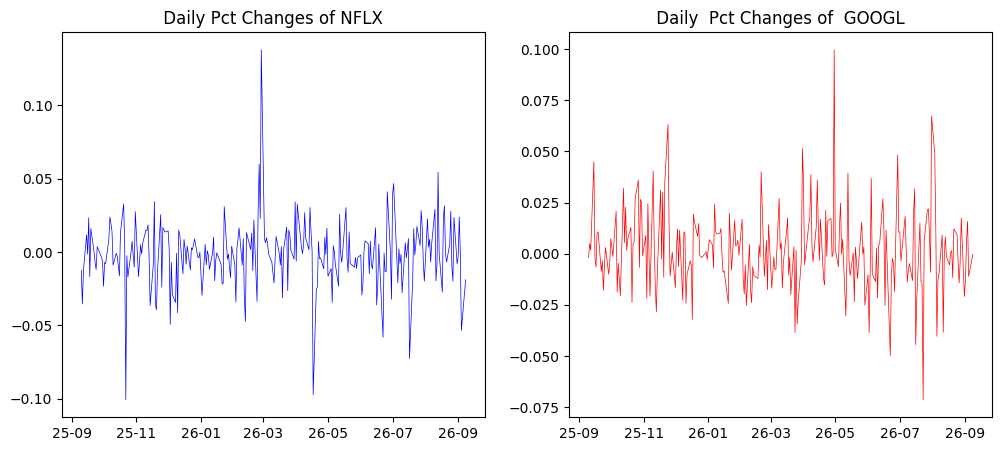

In [22]:

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), sharex=True)
#axes[0].plot(yymmdd, stck_prc, color='blue', linewidth=0.5)
axes[0].plot(yymmdd, stck_prc_1.pct_change(), color='blue', linewidth=0.5)
#axes[1].plot(yymmdd, stck_vlm, color='red', linewidth=0.5)
axes[1].plot(yymmdd, stck_prc_2.pct_change(), color='red', linewidth=0.5)

# axes[0].set_title(f" Closing Prices of {ticker} ")
axes[0].set_title(f" Daily Pct Changes of NFLX ")
axes[1].set_title(f" Daily  Pct Changes of  GOOGL ")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
#axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
#axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%y/%m'))


### distibution of daily price changes

Text(0.5, 1.0, ' distribution of daily percentage change of MU ')

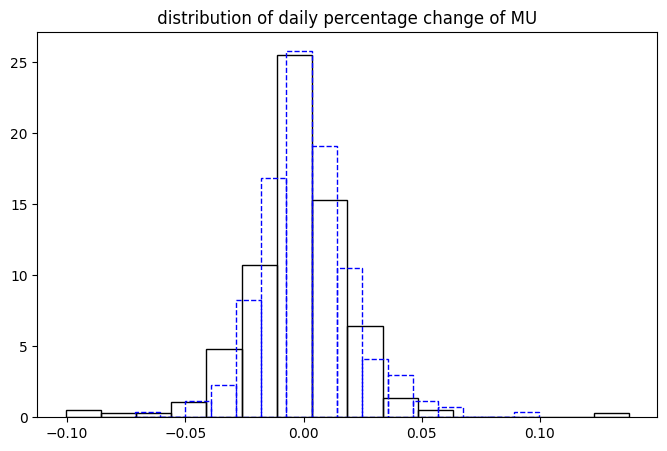

In [27]:

plt.figure(figsize=(8, 5))
plt.hist(stck_prc_1.pct_change(), color='blue', linewidth=1, bins = 16, facecolor='None', edgecolor='black', density=True)
plt.hist(stck_prc_2.pct_change(), color='blue', linewidth=1, bins = 16, facecolor='None', edgecolor='blue', density=True, linestyle='--')
plt.title(f" distribution of daily percentage change of {ticker} ")
